<a href="https://colab.research.google.com/github/amitsangani/Llama/blob/main/Llama_2_Fine_Tune_With_Your_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practical Introduction to Llama 2 Fine-Tuning**

## **How to fine-tune Llama 2 🦙**
In this section, we will fine-tune a 7B parameter Llama 2 model on a T4 GPU with high RAM using Google Colab. Note that a T4 only has 16 GB of VRAM, which is barely enough to store Llama 2–7b’s weights (7b × 2 bytes = 14 GB in FP16). In addition, we need to consider the overhead due to optimizer states, gradients, and forward activations (see this excellent article for more information). This means that a full fine-tuning is not possible here: we need parameter-efficient fine-tuning (PEFT) techniques like LoRA or QLoRA.

To drastically reduce the VRAM usage, we must fine-tune the model in 4-bit precision, which is why we’ll use QLoRA here. The good thing is that we can leverage the Hugging Face ecosystem with the transformers, accelerate, peft, trl, and bitsandbytes libraries. First, we install and load these libraries.

In [1]:
# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login
import json

# Login to HuggingFace
hf_token = os.getenv('HF_TOKEN')
# if hf_token:
#     login(token=hf_token)
#     print("Logged in to HuggingFace")
# else:
#     print("Warning: HF_TOKEN not found in .env file")

# Set your HuggingFace username/organization
HF_USERNAME = os.getenv('HF_USERNAME', 'your-username')  # Change this to your HF username
# Set HF cache FIRST
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    HfArgumentParser,
    TrainingArguments,
    pipeline,
    logging,
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer


Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


QLoRA will use a rank of 64 with a scaling parameter of 16 (see this article for more information about LoRA parameters). We’ll load the Llama 2 model directly in 4-bit precision using the NF4 type and train it for one epoch. To get more information about the other parameters, check the TrainingArguments, PeftModel, and SFTTrainer documentation.


In [2]:
# The model that you want to train from the Hugging Face hub
model_name = "meta-llama/Llama-2-7b-chat-hf"

# The cocktails dataset
dataset_name = "jrosseruk/cocktails-with-instructions"

# Fine-tuned model name
new_model = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune"

In [3]:
################################################################################
# QLoRA parameters
################################################################################

# LoRA attention dimension
lora_r = 8

# Alpha parameter for LoRA scaling
lora_alpha = 16

# Dropout probability for LoRA layers
lora_dropout = 0.1

In [4]:
################################################################################
# bitsandbytes parameters
################################################################################

# Activate 4-bit precision base model loading
use_4bit = True

# Compute dtype for 4-bit base models
bnb_4bit_compute_dtype = "float16"

# Quantization type (fp4 or nf4)
bnb_4bit_quant_type = "nf4"

# Activate nested quantization for 4-bit base models (double quantization)
use_nested_quant = False

In [5]:
################################################################################
# TrainingArguments parameters
################################################################################

# Output directory where the model predictions and checkpoints will be stored
output_dir = "/lus/lfs1aip2/home/s5e/jrosser.s5e/llama_2/results"

# Number of training epochs
num_train_epochs = 10

# Enable fp16/bf16 training (set bf16 to True with an A100)
fp16 = False
bf16 = True

# Batch size per GPU for training
per_device_train_batch_size = 4

# Batch size per GPU for evaluation
per_device_eval_batch_size = 4

# Number of update steps to accumulate the gradients for
gradient_accumulation_steps = 1

# Enable gradient checkpointing
gradient_checkpointing = True

# Maximum gradient normal (gradient clipping)
max_grad_norm = 0.3

# Initial learning rate (AdamW optimizer)
learning_rate = 2e-4

# Weight decay to apply to all layers except bias/LayerNorm weights
weight_decay = 0.001

# Optimizer to use
optim = "paged_adamw_32bit"

# Learning rate schedule
lr_scheduler_type = "constant" 

# Number of training steps (overrides num_train_epochs)
max_steps = -1

# Ratio of steps for a linear warmup (from 0 to learning rate)
warmup_ratio = 0.03

# Group sequences into batches with same length
# Saves memory and speeds up training considerably
group_by_length = True

# Save checkpoint every X updates steps
save_steps = 100

# Log every X updates steps
logging_steps = 25

In [6]:
################################################################################
# SFT parameters
################################################################################

# Maximum sequence length to use
max_seq_length = 2048

# Pack multiple short examples in the same input sequence to increase efficiency
packing = False

# Load the entire model on the GPU 0
device_map = {"": 0}

# **We can now start a fine-tuning process**

1. Load the pre-processed dataset.
2. Configure bitsandbytes for 4-bit quantization
3. Load Llama 2 model in 4-bit precision on a GPU with tokenizer
4. Load configurations for QLoRA, regular training params using SFTTrainer

In [7]:
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer
from collections import Counter

# Load the cocktails dataset
ds = load_dataset(dataset_name)
df = ds["train"].to_pandas()

# Filter to only use cocktails with top N most common ingredients
N = 50

# Parse the ingredients column from string to actual lists
df['ingredients_list'] = df['ingredients'].apply(lambda x: [ing[1] for ing in eval(x)])

# Flatten all ingredients and count them
all_ingredients = []
for ingredients in df['ingredients_list']:
    all_ingredients.extend(ingredients)

ingredient_counts = Counter(all_ingredients)

# Get the N most common ingredients
top_N_ingredients = set([ing for ing, count in ingredient_counts.most_common(N)])
print(f"Top {N} ingredients: {len(top_N_ingredients)}")
print(ingredient_counts.most_common(20))  # Show top 20 for preview

# Filter recipes that only contain ingredients from the top N
def all_ingredients_in_top_N(ingredients_list):
    return all(ing in top_N_ingredients for ing in ingredients_list)

df_filtered = df[df['ingredients_list'].apply(all_ingredients_in_top_N)].copy()

print(f"\nOriginal cocktails: {len(df)}")
print(f"Filtered cocktails (only top {N} ingredients): {len(df_filtered)}")

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
messages_list = []
skipped_long = 0
skipped_error = 0

for _, row in df_filtered.iterrows():
    try:
        # Get synthetic instructions
        instructions_text = row["synthetic_instructions"]
        
        # skip very short / broken recipes
        if len(instructions_text) < 50:
            continue

        # Get ingredients list
        ingredients = row['ingredients_list']
        if not ingredients:
            continue

        # USER: title + instructions, ask to extract ingredients only
        user_message = {
            "role": "user",
            "content": f"""You will be given the title of a cocktail recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {row['title']}

Instructions:
{instructions_text}
"""
        }

        # ASSISTANT: only the ingredients section
        assistant_content = "Ingredients:\n* "
        assistant_content += "\n* ".join(ingredients)
        assistant_content += "\nEND"

        assistant_message = {
            "role": "assistant",
            "content": assistant_content
        }

        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False,
        )

        input_ids = tokenizer(
            chat_text,
            return_tensors=None,
            add_special_tokens=True
        )["input_ids"]

        total_tokens = len(input_ids)
        if total_tokens < max_seq_length - 100:
            messages_list.append([user_message, assistant_message])
        else:
            skipped_long += 1

    except Exception as e:
        skipped_error += 1

print(f"\nFiltered cocktails: {len(df_filtered)} examples")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")

dataset = Dataset.from_dict({"messages": messages_list})
print(f"Dataset created with {len(dataset)} examples")
print(dataset[0]["messages"][1]["content"])

README.md:   0%|          | 0.00/471 [00:00<?, ?B/s]

Top 50 ingredients: 50
[('Lemon juice (freshly squeezed)', 1697), ('Lime juice (freshly squeezed)', 1627), ('Sugar syrup (65.0°brix, 2 sugar to 1 water rich syrup)', 1427), ('Rutte Dry Gin', 847), ('Angostura Aromatic Bitters', 621), ('Ketel One Vodka', 584), ('Bacardi Carta Blanca light rum', 507), ('Orange juice (freshly squeezed)', 491), ('Rémy Martin 1738 Cognac', 471), ('Pineapple juice (fresh pressed)', 440), ('Martini Extra Dry vermouth', 433), ('Bourbon whiskey', 432), ('Martini Rosso sweet vermouth', 407), ('Orange Bitters by Angostura', 382), ('De Kuyper Triple Sec (40%)', 379), ('Pasteurised egg white', 345), ('Luxardo Maraschino liqueur', 272), ('Apple juice', 267), ('Grapefruit juice (pink)', 261), ('Gin', 261)]

Original cocktails: 6956
Filtered cocktails (only top 50 ingredients): 797


tokenizer_config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]


Filtered cocktails: 797 examples
Skipped (too long): 0
Skipped (errors): 0
Dataset created with 797 examples
Ingredients:
* La Fée Parisienne absinthe
* Chilled water
* Sugar syrup (65.0°brix, 2 sugar to 1 water rich syrup)
END


In [8]:
print(f"{dataset[8]['messages'][1]['content']}")

Ingredients:
* Ketel One Vodka
* Coffee liqueur
* Dutch Cacao white crème de cacao
* Single cream / half-and-half
END


In [9]:
# Step 2: configure bitsandbytes for 4-bit quantization

# Load tokenizer and model with QLoRA configuration
compute_dtype = getattr(torch, bnb_4bit_compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=use_4bit,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=use_nested_quant,
)

In [10]:
# Step 3: Load Llama 2 model in 4-bit precision on a GPU with tokenizer

# Check GPU compatibility with bfloat16
if compute_dtype == torch.float16 and use_4bit:
    major, _ = torch.cuda.get_device_capability()
    if major >= 8:
        print("=" * 80)
        print("Your GPU supports bfloat16: accelerate training with bf16=True")
        print("=" * 80)

# Load Llama 2 base model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map
)

model.config.use_cache = False
model.config.pretraining_tp = 1

# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right" # Fix weird overflow issue with fp16 training

Your GPU supports bfloat16: accelerate training with bf16=True


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

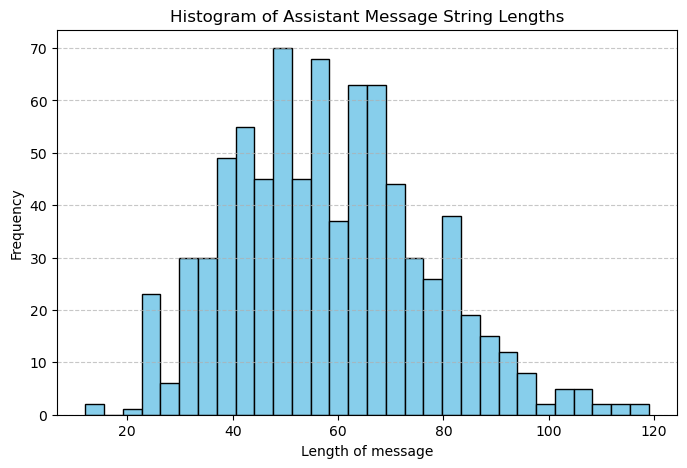

In [11]:
import matplotlib.pyplot as plt

# Calculate the length of each assistant message in messages_list
message_lengths = [len(tokenizer(messages[1]["content"])["input_ids"]) for messages in messages_list]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(message_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Assistant Message String Lengths')
plt.xlabel('Length of message')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [12]:
# Step 4: Load configurations for QLoRA

# Load LoRA configuration
peft_config = LoraConfig(
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    r=lora_r,
    bias="none",
    task_type="CAUSAL_LM",
)

In [13]:
from transformers import TrainerCallback

class SavePerEpochCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        epoch = int(state.epoch)
        model.save_pretrained(f"{new_model}_{epoch}")
        tokenizer.save_pretrained(f"{new_model}_{epoch}")
        print(f"Saved: {new_model}_{epoch}")

save_callback = SavePerEpochCallback()

# Set training parameters
training_arguments = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    optim=optim,
    save_steps=save_steps,
    logging_steps=logging_steps,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    fp16=fp16,
    bf16=bf16,
    max_grad_norm=max_grad_norm,
    max_steps=max_steps,
    warmup_ratio=warmup_ratio,
    group_by_length=group_by_length,
    lr_scheduler_type=lr_scheduler_type,
    report_to="tensorboard",
)

# Set supervised fine-tuning parameters with proper dataset formatting
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    args=training_arguments,
    processing_class=tokenizer,
    callbacks=[save_callback],
)

# Train model
trainer.train()

# Save trained model and tokenizer together
trainer.model.save_pretrained(new_model)
tokenizer.save_pretrained(new_model)
print(f"LoRA weights and tokenizer saved to: {new_model}")

Tokenizing train dataset:   0%|          | 0/797 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/797 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
25,1.432900
50,0.818100
75,0.603400
100,0.657800
125,0.546700
150,0.602500
175,0.515300
200,0.579200
225,0.452700
250,0.523100


Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_1
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_2
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_3
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_4
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_5
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_6
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_7
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_8
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_9
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune_10
LoRA weights and tokenizer saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-cocktails-finetune


# **Training Progress**

Training will take time depending on your dataset size and hardware. You can monitor progress through the training logs. The model will save checkpoints periodically.

# **Merge LoRA Weights with Base Model**

After training, we need to merge the LoRA weights with the base model to create a complete finetuned model. We reload the base model in FP16 precision and use PEFT to merge everything.

In [14]:
# Reload model in FP16 and merge it with LoRA weights
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map=device_map,
)
model = PeftModel.from_pretrained(base_model, new_model)
model = model.merge_and_unload()

# Reload tokenizer to save it
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [15]:
# Test the merged model with a question from the training data
logging.set_verbosity(logging.CRITICAL)

print("Testing merged model:")
print("=" * 80)

# Test with a prompt that should trigger training data knowledge
prompt = user_message
pipe_test = pipeline(task="text-generation",
        model=model,
        tokenizer=tokenizer,
        max_length=512,
        do_sample=False,          # Deterministic: use greedy decoding
        num_beams=1,              # No beam search, pure greedy
        temperature=1.0,          # Not used when do_sample=False
        top_k=0,                  # Not used when do_sample=False
        top_p=1.0,                # Not used when do_sample=False
)
result = pipe_test(f"<s>[INST] {prompt} [/INST]")
print(f"Prompt: {prompt}\n")
print(f"Response:\n{result[0]['generated_text']}")
print("\n" + "=" * 80)

Testing merged model:
Prompt: {'role': 'user', 'content': 'You will be given the title of a cocktail recipe and its step-by-step instructions.\nExtract the ingredients list ONLY, one ingredient per line, in this exact format:\n\nIngredients:\n* ingredient 1\n* ingredient 2\nEND\n\nTitle: The Anniversary\n\nInstructions:\nFill a shaker with ice and add bourbon whiskey, Martini Rosso sweet vermouth, De Kuyper Apricot Brandy liqueur, freshly squeezed lemon juice, Giffard Grenadine, and a couple dashes of orange bitters. Shake vigorously until well chilled, then strain through a fine mesh into a chilled coupe glass to keep the drink silky smooth. The sweet and fruity notes from the vermouth and apricot liqueur mingle with the warmth of the bourbon, while the lemon brightens and the grenadine adds a kiss of color and sweetness. Garnish with a Luxardo maraschino cherry for a classic finishing touch and serve. Enjoy responsibly.\n'}

Response:
<s>[INST] {'role': 'user', 'content': 'You will b

# **Compare Base Model vs Finetuned Model**

Let's load the original base model and compare its responses with the finetuned model to see the impact of training.

In [18]:
import random

# Load a fresh base model for comparison
print("Loading base model (untrained)...")
base_model_compare = AutoModelForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map={"": 0},
)

tokenizer_compare = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer_compare.pad_token = tokenizer_compare.eos_token
tokenizer_compare.padding_side = "right"

logging.set_verbosity(logging.CRITICAL)

# Select 10 random prompts from the dataset (no duplicates)
num_samples = min(10, len(messages_list))
random_indices = random.sample(range(len(messages_list)), num_samples)

print("\n" + "="*100)
print("COMPARISON: BASE MODEL vs FINETUNED MODEL")
print(f"Using random sample indices: {random_indices}")
print("="*100)

for idx_number, random_idx in enumerate(random_indices, 1):
    random_sample = messages_list[random_idx]
    test_prompt = random_sample[0]["content"]  # User message content
    expected_response = random_sample[1]["content"]  # Assistant message (ground truth)
    
    print(f"\n\nSAMPLE {idx_number} (index {random_idx})")
    print("-" * 100)
    print(f"Prompt:\n{test_prompt}")
    print("\n" + "-"*100)
    
    # Base model response (deterministic)
    print("\nBASE MODEL (Before Finetuning):")
    print("-"*100)
    pipe_base = pipeline(
        task="text-generation",
        model=base_model_compare,
        tokenizer=tokenizer_compare,
        max_length=500,
        do_sample=False,          # Deterministic: use greedy decoding
        num_beams=1,              # No beam search, pure greedy
        temperature=1.0,          # Not used when do_sample=False
        top_k=0,                  # Not used when do_sample=False
        top_p=1.0,                # Not used when do_sample=False
    )
    result_base = pipe_base(f"<s>[INST] {test_prompt} [/INST]")
    print(result_base[0]['generated_text'])
    
    # Finetuned model response (already loaded as 'model')
    print("\n" + "-"*100)
    print("FINETUNED MODEL (After Training):")
    print("-"*100)
    pipe_finetuned = pipeline(
        task="text-generation",
        model=model,
        tokenizer=tokenizer,
        max_length=500,
        do_sample=False,       # Deterministic: use greedy decoding
        num_beams=1,           # No beam search, pure greedy
        temperature=1.0,       # Not used when do_sample=False
        top_k=0,               # Not used when do_sample=False
        top_p=1.0,             # Not used when do_sample=False
    )
    result_finetuned = pipe_finetuned(f"<s>[INST] {test_prompt} [/INST]")
    print(result_finetuned[0]['generated_text'])
    
    # Show expected response from training data
    print("\n" + "-"*100)
    print("EXPECTED RESPONSE (Ground Truth from Training Data):")
    print("-"*100)
    print(expected_response)
    print("\n" + "="*100)

print("\n\nComparison complete! The finetuned model should produce output closer to the expected responses.")

Loading base model (untrained)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


COMPARISON: BASE MODEL vs FINETUNED MODEL
Using random sample indices: [114, 25, 759, 281, 250, 228, 142, 754, 104, 692]


SAMPLE 1 (index 114)
----------------------------------------------------------------------------------------------------
Prompt:
You will be given the title of a cocktail recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: Covadonga

Instructions:
Fill a martini glass with a little chill to get it frosty, then set it aside as you gather the ingredients for the Covadonga. In a shaker, combine the Italian red bitter liqueur, Martini Rosso sweet vermouth, freshly squeezed orange juice, Giffard grenadine, and Angostura bitters. Add plenty of ice, then shake vigorously until well chilled and slightly diluted. Fine strain the mix into the chilled martini glass to keep it clean and smooth. Crown the drink with a bright orange slice on the rim f